# Wind Conditions and Tidal Context

This notebook analyzes wind forcing and sea-surface-height variability to characterize environmental conditions during selected July and November windows in the Iceland3 simulation.

- Load model history and surface forcing files for target periods
- Compute domain-mean SSH, wind speed, and wind-direction diagnostics
- Estimate tidal-range statistics from SSH extrema
- Compare conditions across candidate release windows

This cell loads model history data, computes domain-mean sea-surface height, and plots its time evolution.

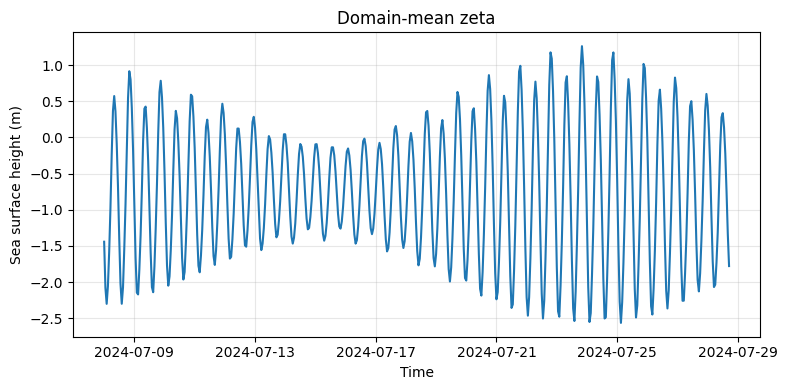

In [16]:
HIS_JULY_GLOB='/home/x-uheede/S/Iceland3_MARBL_2024/Iceland3_MARBL_2024_his.202407????????.nc'
HIS_NOV_GLOB='/home/x-uheede/S/Iceland3_MARBL_2024/Iceland3_MARBL_2024_his.202411????????.nc'
GRID_PATH='/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc'

SURFACE_FORCING_JULY_PATH='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202407.nc'
SURFACE_FORCING_NOV_PATH='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202411.nc'
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
x=xr.open_mfdataset(HIS_JULY_GLOB, combine='nested', concat_dim=["time"])
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)
zeta = x["zeta"]

# --------------------------------
# Mask zero values
# --------------------------------
zeta_nonzero = zeta.where(zeta != 0)

# --------------------------------
# Domain mean of non-zero cells
# --------------------------------
zeta_mean = zeta_nonzero.mean(
    dim=["eta_rho", "xi_rho"],
    skipna=True
)
plt.figure(figsize=(8,4))
plt.plot(x['ocean_time'], zeta_mean)
plt.ylabel("Sea surface height (m)")
plt.xlabel("Time")
plt.title("Domain-mean zeta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This cell computes surface and bottom hydrography summaries and estimates bulk water-column stratification.

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import seawater as sw

# 1. Load the dataset
x = xr.open_mfdataset(
    HIS_JULY_GLOB, 
    combine='nested', 
    concat_dim=["time"]
)

# Fix time coordinates
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)

# 2. Extract Surface and Bottom layers
# Surface (s_rho = 59), Bottom (s_rho = 0)
temp_surf = x["temp"].isel(s_rho=59)
salt_surf = x["salt"].isel(s_rho=59)

temp_bot = x["temp"].isel(s_rho=0)
salt_bot = x["salt"].isel(s_rho=0)

# 3. Mask zero values (Land mask/Invalid data)
# We mask where salt is 0, as it is a reliable indicator of the land mask in ROMS
mask = (salt_surf != 0) & (salt_bot != 0)

temp_surf_masked = temp_surf.where(mask)
salt_surf_masked = salt_surf.where(mask)
temp_bot_masked = temp_bot.where(mask)
salt_bot_masked = salt_bot.where(mask)

# 4. Domain Average (Spatial Mean)
# Calculate the mean across the horizontal grid for each time step
surf_temp_ts = temp_surf_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
surf_salt_ts = salt_surf_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
bot_temp_ts = temp_bot_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
bot_salt_ts = salt_bot_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)

# 5. Time Average
# Reduce the time series to a single average value for the period
avg_temp_surf = surf_temp_ts.mean().values
avg_salt_surf = surf_salt_ts.mean().values
avg_temp_bot = bot_temp_ts.mean().values
avg_salt_bot = bot_salt_ts.mean().values

# 6. Calculate Density using seawater (sw.dens)
# sw.dens(S, T, P) -> P is pressure in decibars. 
# For surface use 0, for bottom we can approximate or use 0 for potential density (sigma-t)
rho_surf = sw.dens(avg_salt_surf, avg_temp_surf, 0)
rho_bot = sw.dens(avg_salt_bot, avg_temp_bot, 0)

stratification = rho_bot - rho_surf

# 7. Summary Output
print("--- Water Column Stratification Summary ---")
print(f"Surface: Temp = {avg_temp_surf:.2f}°C, Salt = {avg_salt_surf:.2f} psu")
print(f"Bottom:  Temp = {avg_temp_bot:.2f}°C, Salt = {avg_salt_bot:.2f} psu")
print("-" * 43)
print(f"Surface Density: {rho_surf:.3f} kg/m^3")
print(f"Bottom Density:  {rho_bot:.3f} kg/m^3")
print(f"Average Δρ (Stratification): {stratification:.3f} kg/m^3")

/tmp/ipykernel_76924/3174314243.py:4: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


--- Water Column Stratification Summary ---
Surface: Temp = 11.98°C, Salt = 33.39 psu
Bottom:  Temp = 11.55°C, Salt = 34.42 psu
-------------------------------------------
Surface Density: 1025.342 kg/m^3
Bottom Density:  1026.221 kg/m^3
Average Δρ (Stratification): 0.879 kg/m^3


This cell computes surface and bottom hydrography summaries and estimates bulk water-column stratification.

In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import seawater as sw


# 1. Load the dataset
x = xr.open_mfdataset(
    HIS_NOV_GLOB, 
    combine='nested', 
    concat_dim=["time"]
)

# Fix time coordinates
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)

# 2. Extract Surface and Bottom layers
# Surface (s_rho = 59), Bottom (s_rho = 0)
temp_surf = x["temp"].isel(s_rho=59)
salt_surf = x["salt"].isel(s_rho=59)

temp_bot = x["temp"].isel(s_rho=0)
salt_bot = x["salt"].isel(s_rho=0)

# 3. Mask zero values (Land mask/Invalid data)
# We mask where salt is 0, as it is a reliable indicator of the land mask in ROMS
mask = (salt_surf != 0) & (salt_bot != 0)

temp_surf_masked = temp_surf.where(mask)
salt_surf_masked = salt_surf.where(mask)
temp_bot_masked = temp_bot.where(mask)
salt_bot_masked = salt_bot.where(mask)

# 4. Domain Average (Spatial Mean)
# Calculate the mean across the horizontal grid for each time step
surf_temp_ts = temp_surf_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
surf_salt_ts = salt_surf_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
bot_temp_ts = temp_bot_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)
bot_salt_ts = salt_bot_masked.mean(dim=["eta_rho", "xi_rho"], skipna=True)

# 5. Time Average
# Reduce the time series to a single average value for the period
avg_temp_surf = surf_temp_ts.mean().values
avg_salt_surf = surf_salt_ts.mean().values
avg_temp_bot = bot_temp_ts.mean().values
avg_salt_bot = bot_salt_ts.mean().values

# 6. Calculate Density using seawater (sw.dens)
# sw.dens(S, T, P) -> P is pressure in decibars. 
# For surface use 0, for bottom we can approximate or use 0 for potential density (sigma-t)
rho_surf = sw.dens(avg_salt_surf, avg_temp_surf, 0)
rho_bot = sw.dens(avg_salt_bot, avg_temp_bot, 0)

stratification = rho_bot - rho_surf

# 7. Summary Output
print("--- Water Column Stratification Summary ---")
print(f"Surface: Temp = {avg_temp_surf:.2f}°C, Salt = {avg_salt_surf:.2f} psu")
print(f"Bottom:  Temp = {avg_temp_bot:.2f}°C, Salt = {avg_salt_bot:.2f} psu")
print("-" * 43)
print(f"Surface Density: {rho_surf:.3f} kg/m^3")
print(f"Bottom Density:  {rho_bot:.3f} kg/m^3")
print(f"Average Δρ (Stratification): {stratification:.3f} kg/m^3")

--- Water Column Stratification Summary ---
Surface: Temp = 4.74°C, Salt = 33.74 psu
Bottom:  Temp = 4.97°C, Salt = 33.95 psu
-------------------------------------------
Surface Density: 1026.705 kg/m^3
Bottom Density:  1026.847 kg/m^3
Average Δρ (Stratification): 0.142 kg/m^3


This cell derives section transport from velocity and layer thickness and summarizes westward mass transport.

--- Westward Mass Transport at xi_u=100 ---
Average Total Westward Transport: -3.83e+08 kg/s
Equivalent to: -1377.16 Tg/h


Text(0.5, 0, 'eta_rho')

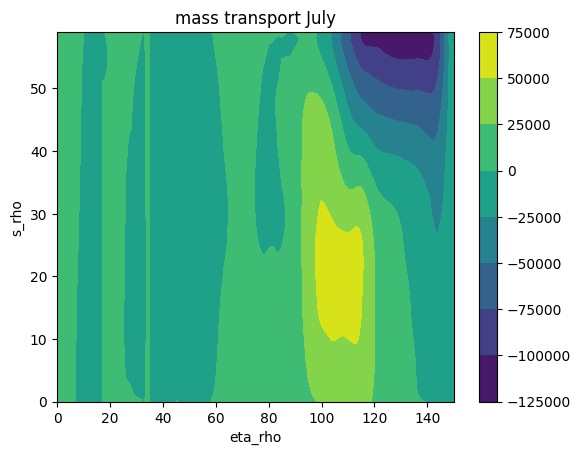

In [6]:
import xarray as xr
import numpy as np

model_grid_path=GRID_PATH
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300


# =====================================================
# 1. Load Data
# =====================================================
his_path = HIS_JULY_GLOB
grid_path = model_grid_path 

ds_grid = xr.open_dataset(grid_path)
# Extract u and zeta at the slice
ds_his = xr.open_mfdataset(his_path, combine='nested', concat_dim='time').isel(xi_u=100, xi_rho=100)

# =====================================================
# 2. Extract Geometry & Physics
# =====================================================
u = ds_his["u"]              # Velocity (m/s)
zeta = ds_his["zeta"]        # Sea surface height (m)
h = ds_grid["h"].isel(xi_rho=100)
pn = ds_grid["pn"].isel(xi_rho=100)
dy = 1.0 / pn                # Cell width in meters (eta direction)

rho_const = 1026             # kg/m^3

# Vertical coordinate parameters for thickness
hc = hc_model
s_w = ds_grid["s_w"]
Cs_w = ds_grid["Cs_w"]

# =====================================================
# 3. Calculate Cell Thickness (dz)
# =====================================================
S_w = (hc * s_w + h * Cs_w) / (hc + h)
zw = zeta + (zeta + h) * S_w
dz = zw.diff(dim="s_w").rename({"s_w": "s_rho"})

# =====================================================
# 4. Calculate Westward Mass Transport
# =====================================================
# Mass Transport (kg/s) = rho * u * dy * dz
# We only care about negative u (westward flow)
u_west = u#.where(u < 0, 0)

# Compute transport per cell
# dimensions: (time, s_rho, eta_rho)
mass_transport_cells = rho_const * u_west * dy * dz

# Sum over depth (s_rho) and along the slice (eta_rho)
# result is a timeseries of total westward mass transport (kg/s)
total_westward_transport_ts = mass_transport_cells.where(mass_transport_cells<0).sum(dim=["s_rho", "eta_rho"], skipna=True)

# =====================================================
# 5. Summary
# =====================================================
avg_transport = total_westward_transport_ts.mean().values
print(f"--- Westward Mass Transport at xi_u=100 ---")
print(f"Average Total Westward Transport: {avg_transport:.2e} kg/s")

# For scale, convert to Teragrams per hour (Tg/h)
tg_per_hour = (avg_transport * 3600) / 1e9
print(f"Equivalent to: {tg_per_hour:.2f} Tg/h")

cf=plt.contourf(mass_transport_cells.mean('time'))
plt.xlim(0,150)
plt.colorbar(cf)
plt.title('mass transport July')
plt.ylabel('s_rho')
plt.xlabel('eta_rho')

This cell derives section transport from velocity and layer thickness and summarizes westward mass transport.

--- Westward Mass Transport at xi_u=100 ---
Average Total Westward Transport: -3.84e+08 kg/s
Equivalent to: -1383.23 Tg/h


Text(0.5, 0, 'eta_rho')

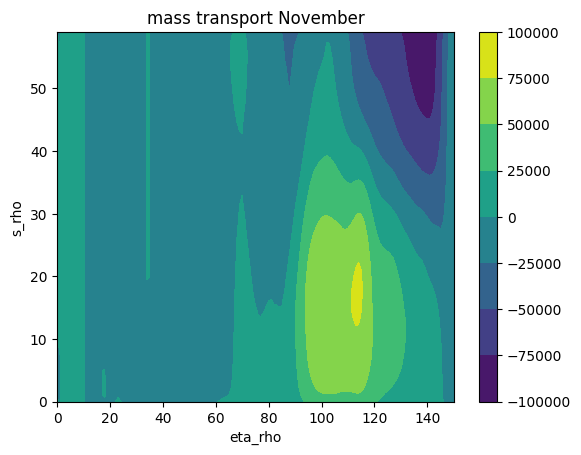

In [7]:
import xarray as xr
import numpy as np

model_grid_path=GRID_PATH
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300


# =====================================================
# 1. Load Data
# =====================================================
his_path = HIS_NOV_GLOB
grid_path = model_grid_path 

ds_grid = xr.open_dataset(grid_path)
# Extract u and zeta at the slice
ds_his = xr.open_mfdataset(his_path, combine='nested', concat_dim='time').isel(xi_u=100, xi_rho=100)

# =====================================================
# 2. Extract Geometry & Physics
# =====================================================
u = ds_his["u"]              # Velocity (m/s)
zeta = ds_his["zeta"]        # Sea surface height (m)
h = ds_grid["h"].isel(xi_rho=100)
pn = ds_grid["pn"].isel(xi_rho=100)
dy = 1.0 / pn                # Cell width in meters (eta direction)

rho_const = 1026             # kg/m^3

# Vertical coordinate parameters for thickness
hc = hc_model
s_w = ds_grid["s_w"]
Cs_w = ds_grid["Cs_w"]

# =====================================================
# 3. Calculate Cell Thickness (dz)
# =====================================================
S_w = (hc * s_w + h * Cs_w) / (hc + h)
zw = zeta + (zeta + h) * S_w
dz = zw.diff(dim="s_w").rename({"s_w": "s_rho"})

# =====================================================
# 4. Calculate Westward Mass Transport
# =====================================================
# Mass Transport (kg/s) = rho * u * dy * dz
# We only care about negative u (westward flow)
u_west = u

# Compute transport per cell
# dimensions: (time, s_rho, eta_rho)
mass_transport_cells = rho_const * u_west * dy * dz

# Sum over depth (s_rho) and along the slice (eta_rho)
# result is a timeseries of total westward mass transport (kg/s)
total_westward_transport_ts = mass_transport_cells.where(mass_transport_cells<0).sum(dim=["s_rho", "eta_rho"], skipna=True)

# =====================================================
# 5. Summary
# =====================================================
avg_transport = total_westward_transport_ts.mean().values
print(f"--- Westward Mass Transport at xi_u=100 ---")
print(f"Average Total Westward Transport: {avg_transport:.2e} kg/s")

# For scale, convert to Teragrams per hour (Tg/h)
tg_per_hour = (avg_transport * 3600) / 1e9
print(f"Equivalent to: {tg_per_hour:.2f} Tg/h")

cf=plt.contourf(mass_transport_cells.mean('time'))
plt.xlim(0,150)
plt.colorbar(cf)
plt.title('mass transport November')
plt.ylabel('s_rho')
plt.xlabel('eta_rho')


This cell loads required model datasets and prepares variables for subsequent analysis.

In [17]:
a=xr.open_mfdataset(SURFACE_FORCING_JULY_PATH)
a



/tmp/ipykernel_76924/3620924766.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset(SURFACE_FORCING_JULY_PATH)


<xarray.Dataset> Size: 1GB
Dimensions:   (time: 744, eta_rho: 194, xi_rho: 322)
Coordinates:
    abs_time  (time) datetime64[ns] 6kB dask.array<chunksize=(512,), meta=np.ndarray>
  * time      (time) timedelta64[ns] 6kB 8948 days 00:00:00 ... 8978 days 23:...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    uwnd      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    vwnd      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    swrad     (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    lwrad     (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    Tair      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    rain      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    qair      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
Attributes:
    title:                 ROMS surface forcing file created by ROMS-Tools
    roms_tools_version:    3.5.0
    start_time:            2023-12-01 00:00:00
    end_time:              2024-12-31 00:00:00
    source:                ERA5
    correct_radiation:     True
    wind_dropoff:          False
    use_coarse_grid:       True
    model_reference_date:  2000-01-01 00:00:00
    type:                  physics

This cell visualizes the previously computed diagnostics for the selected period.

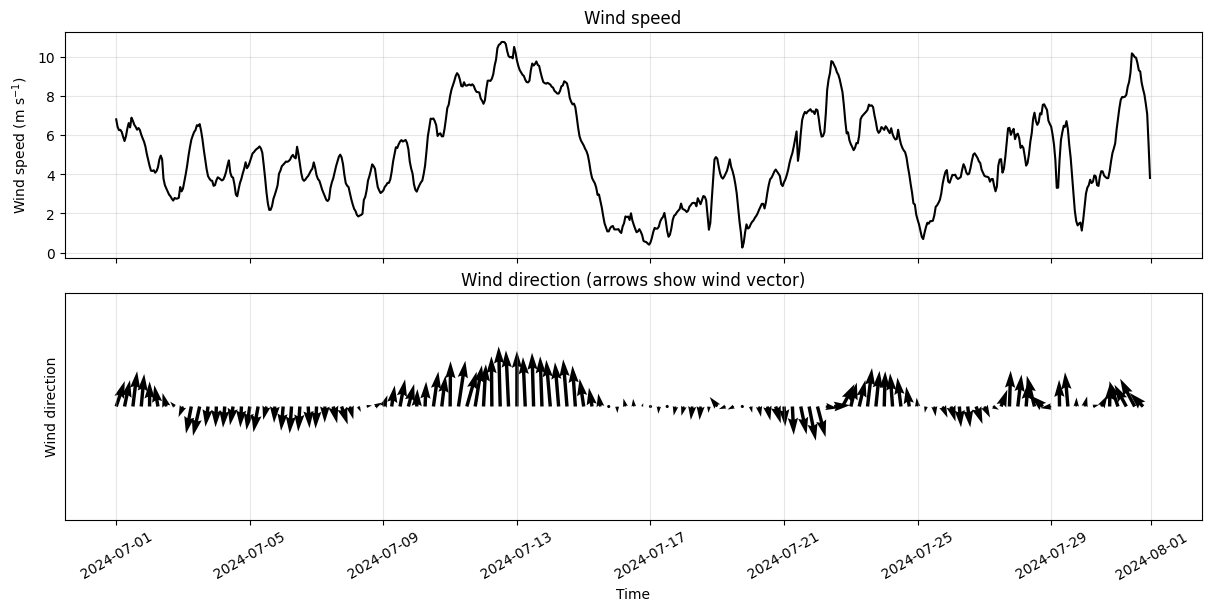

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Domain mean wind
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()

time = a["abs_time"]

# --------------------------------
# Wind speed
# --------------------------------
speed = np.sqrt(u**2 + v**2)

# --------------------------------
# Plot
# --------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(12,6),
    sharex=True,
    constrained_layout=True
)

# ---- Wind speed
axs[0].plot(time, speed, color="k")
axs[0].set_ylabel("Wind speed (m s$^{-1}$)")
axs[0].set_title("Wind speed")
axs[0].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6  # controls arrow density

axs[1].quiver(
    time[::step],
    np.zeros_like(time[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[1].set_ylim(-1, 1)
axs[1].set_yticks([])
axs[1].set_ylabel("Wind direction")
axs[1].set_xlabel("Time")
axs[1].set_title("Wind direction (arrows show wind vector)")
axs[1].grid(alpha=0.3)

plt.xticks(rotation=30)
plt.show()

This cell visualizes the previously computed diagnostics for the selected period.

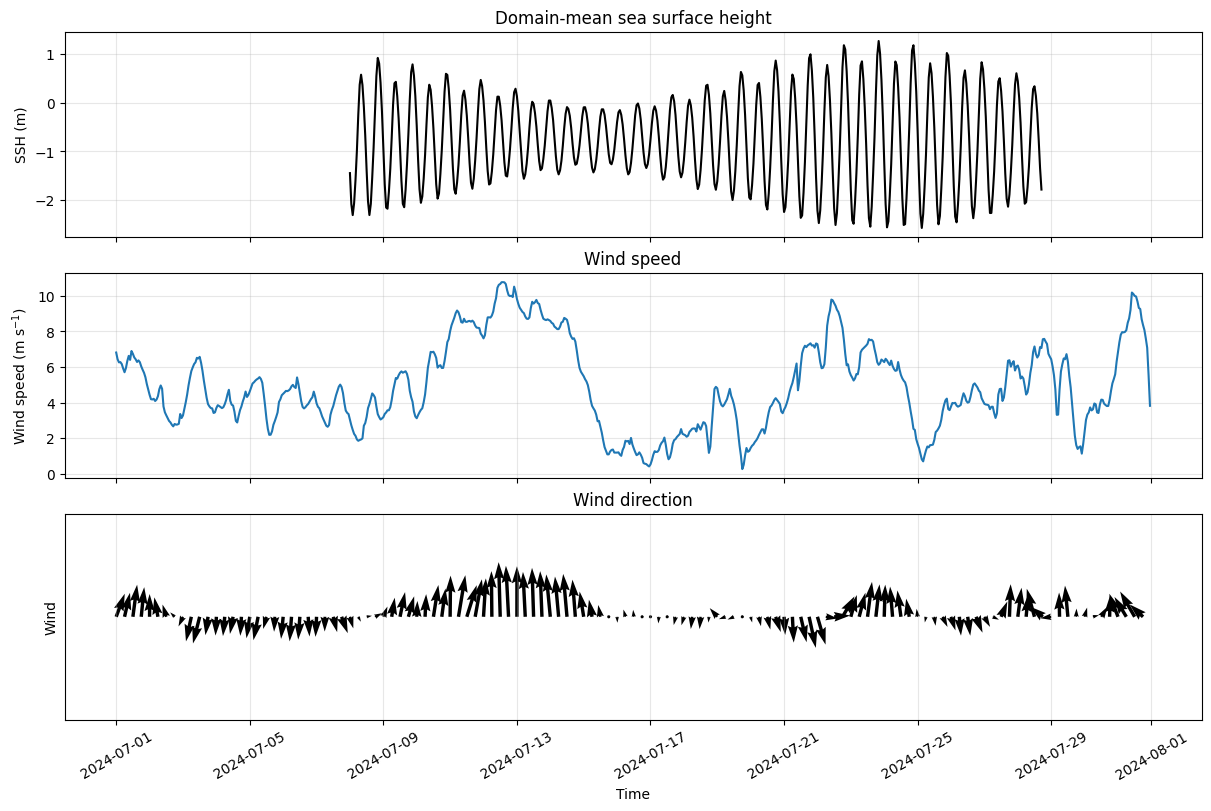

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# --------------------------------
# Wind (domain mean)
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
time_wind = a["abs_time"]

speed = np.sqrt(u**2 + v**2)

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(12,8),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6

axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

plt.xticks(rotation=30)

plt.show()

This cell visualizes the previously computed diagnostics for the selected period.

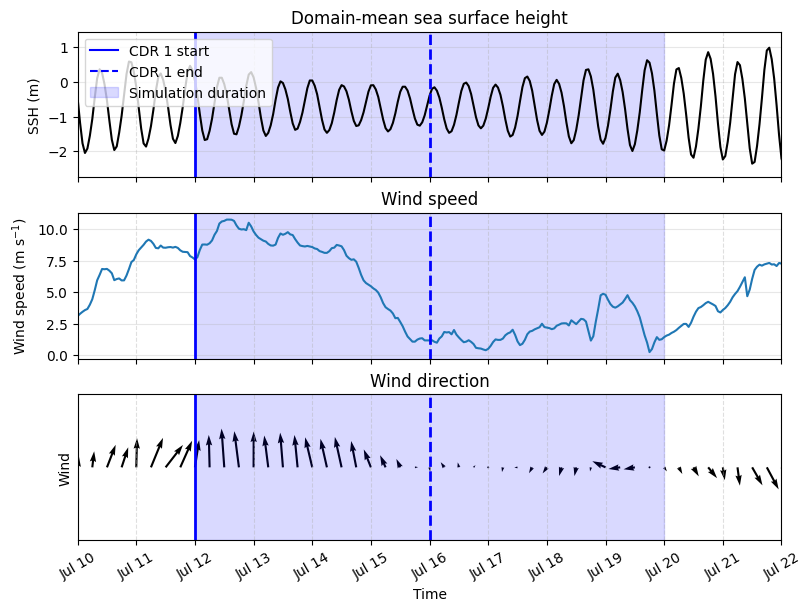

In [20]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-10")
x_end   = np.datetime64("2024-07-22")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-12")
cdr_end   = np.datetime64("2024-07-16")
sim_end   = np.datetime64("2024-07-20")

for ax in axs:
    ax.axvline(cdr_start, color="blue", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="blue", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="blue", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="blue", linestyle="-", label="CDR 1 start")
axs[0].plot([], [], color="blue", linestyle="--", label="CDR 1 end")
axs[0].fill_between([], [], [], color="blue", alpha=0.15, label="Simulation duration")

axs[0].legend()


This cell computes wind and tidal-range statistics over a selected simulation window using SSH extrema.

In [21]:
from scipy.signal import find_peaks

# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-07-12")
cdr_end   = np.datetime64("2024-07-16")
sim_end   = np.datetime64("2024-07-20")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")


--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 4.71 m/s
Most frequent wind direction: 175°

Minimum tidal range:
1.11 m
2024-07-15 20:00:00 → 2024-07-16 02:00:00

Maximum tidal range:
2.62 m
2024-07-19 11:00:00 → 2024-07-19 17:00:00
--------------------------------


This cell visualizes the previously computed diagnostics for the selected period.

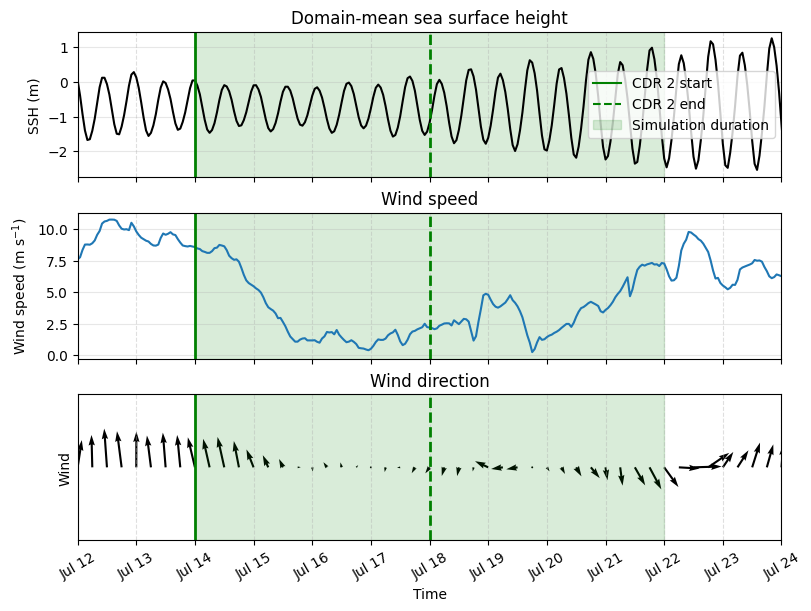

In [22]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-12")
x_end   = np.datetime64("2024-07-24")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-14")
cdr_end   = np.datetime64("2024-07-18")
sim_end   = np.datetime64("2024-07-22")

for ax in axs:
    ax.axvline(cdr_start, color="green", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="green", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="green", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="green", linestyle="-", label="CDR 2 start")
axs[0].plot([], [], color="green", linestyle="--", label="CDR 2 end")
axs[0].fill_between([], [], [], color="green", alpha=0.15, label="Simulation duration")

axs[0].legend()


This cell computes wind and tidal-range statistics over a selected simulation window using SSH extrema.

In [23]:
from scipy.signal import find_peaks

# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-07-14")
cdr_end   = np.datetime64("2024-07-18")
sim_end   = np.datetime64("2024-07-22")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")


--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 3.50 m/s
Most frequent wind direction: 165°

Minimum tidal range:
1.11 m
2024-07-15 20:00:00 → 2024-07-16 02:00:00

Maximum tidal range:
3.35 m
2024-07-21 12:00:00 → 2024-07-21 19:00:00
--------------------------------


This cell visualizes the previously computed diagnostics for the selected period.

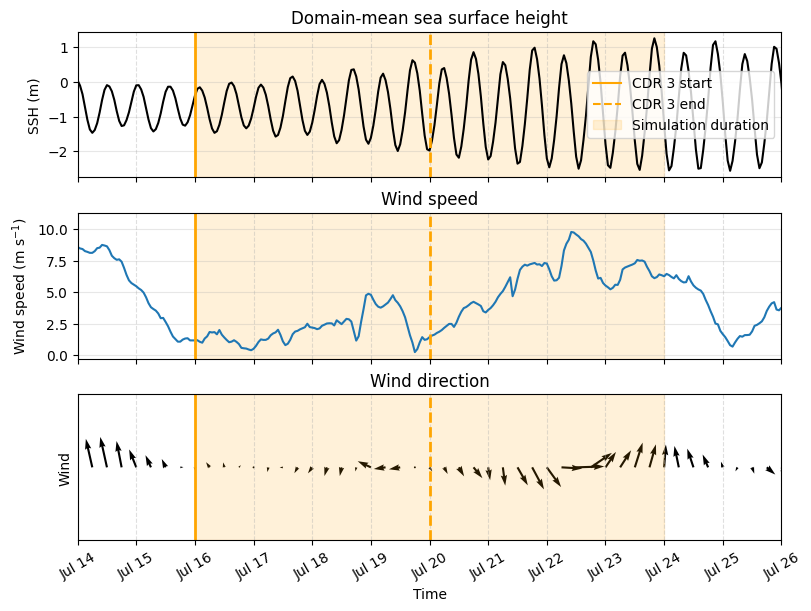

In [24]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-14")
x_end   = np.datetime64("2024-07-26")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-16")
cdr_end   = np.datetime64("2024-07-20")
sim_end   = np.datetime64("2024-07-24")

for ax in axs:
    ax.axvline(cdr_start, color="orange", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="orange", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="orange", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="orange", linestyle="-", label="CDR 3 start")
axs[0].plot([], [], color="orange", linestyle="--", label="CDR 3 end")
axs[0].fill_between([], [], [], color="orange", alpha=0.15, label="Simulation duration")

axs[0].legend()


July 12th: Strong wind from south, medium tides

July 14th: strong winds, low tides

July 16th: Low tides, low wind

July 21st: High tides, strong winds from north

July 24th: High tides, strong winds from south

This cell loads model history data, computes domain-mean sea-surface height, and plots its time evolution.

/tmp/ipykernel_76924/2672942399.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)


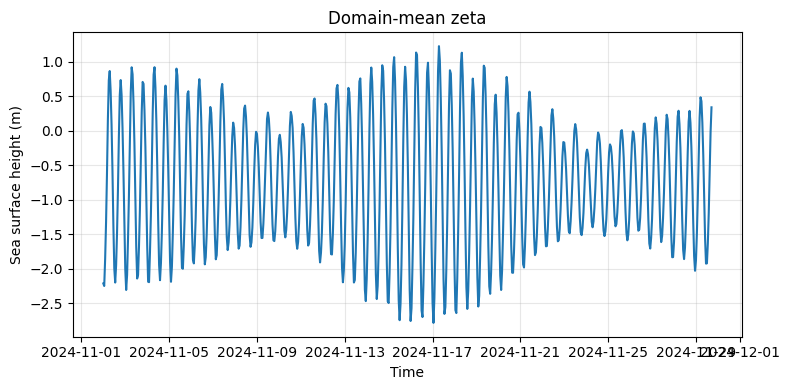

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)
x=xr.open_mfdataset(HIS_NOV_GLOB, combine='nested', concat_dim=["time"])
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)
zeta = x["zeta"]

# --------------------------------
# Mask zero values
# --------------------------------
zeta_nonzero = zeta.where(zeta != 0)

# --------------------------------
# Domain mean of non-zero cells
# --------------------------------
zeta_mean = zeta_nonzero.mean(
    dim=["eta_rho", "xi_rho"],
    skipna=True
)
plt.figure(figsize=(8,4))
plt.plot(x['ocean_time'], zeta_mean)
plt.ylabel("Sea surface height (m)")
plt.xlabel("Time")
plt.title("Domain-mean zeta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This cell loads model history data, computes domain-mean sea-surface height, and plots its time evolution.

In [26]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)

# --------------------------------
# Domain mean wind
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
time_wind = a["abs_time"]
time = a["abs_time"]

# --------------------------------
# Wind speed
# --------------------------------
speed = np.sqrt(u**2 + v**2)


# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-11-05")
cdr_end   = np.datetime64("2024-11-09")
sim_end   = np.datetime64("2024-11-13")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")

/tmp/ipykernel_76924/2667928225.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)



--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 9.05 m/s
Most frequent wind direction: 125°

Minimum tidal range:
1.48 m
2024-11-10 01:00:00 → 2024-11-10 07:00:00

Maximum tidal range:
3.09 m
2024-11-05 02:00:00 → 2024-11-05 08:00:00
--------------------------------


This cell visualizes the previously computed diagnostics for the selected period.

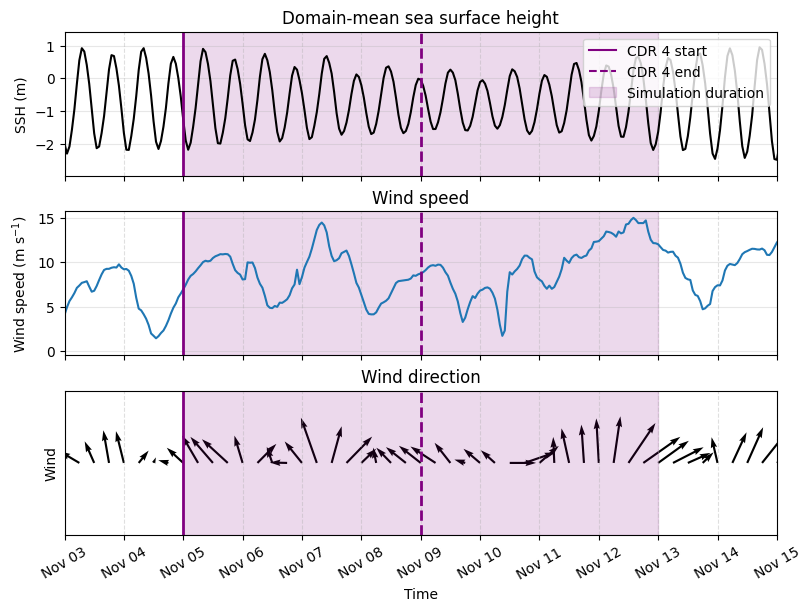

In [27]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-11-03")
x_end   = np.datetime64("2024-11-15")

for ax in axs:
    ax.set_xlim(x_start, x_end)


for ax in axs:
    ax.axvline(cdr_start, color="purple", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="purple", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="purple", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="purple", linestyle="-", label="CDR 4 start")
axs[0].plot([], [], color="purple", linestyle="--", label="CDR 4 end")
axs[0].fill_between([], [], [], color="purple", alpha=0.15, label="Simulation duration")

axs[0].legend()


This cell loads model history data, computes domain-mean sea-surface height, and plots its time evolution.

In [28]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)

# --------------------------------
# Domain mean wind
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
time_wind = a["abs_time"]
time = a["abs_time"]

# --------------------------------
# Wind speed
# --------------------------------
speed = np.sqrt(u**2 + v**2)


# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-11-09")
cdr_end   = np.datetime64("2024-11-13")
sim_end   = np.datetime64("2024-11-17")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")

/tmp/ipykernel_76924/4120308170.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)



--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 9.45 m/s
Most frequent wind direction: 245°

Minimum tidal range:
1.48 m
2024-11-10 01:00:00 → 2024-11-10 07:00:00

Maximum tidal range:
3.89 m
2024-11-16 00:00:00 → 2024-11-16 06:00:00
--------------------------------


This cell visualizes the previously computed diagnostics for the selected period.

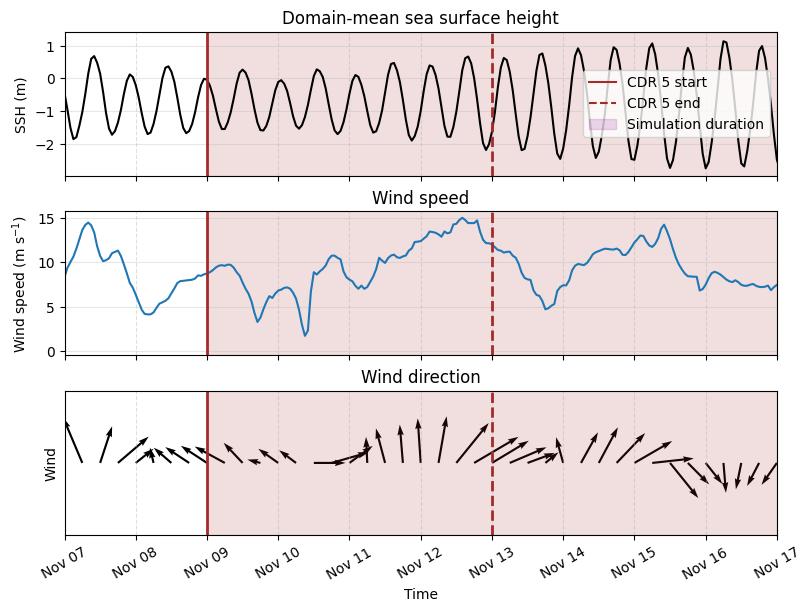

In [29]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-11-07")
x_end   = np.datetime64("2024-11-17")

for ax in axs:
    ax.set_xlim(x_start, x_end)


for ax in axs:
    ax.axvline(cdr_start, color="brown", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="brown", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="brown", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="brown", linestyle="-", label="CDR 5 start")
axs[0].plot([], [], color="brown", linestyle="--", label="CDR 5 end")
axs[0].fill_between([], [], [], color="purple", alpha=0.15, label="Simulation duration")

axs[0].legend()


This cell loads model history data, computes domain-mean sea-surface height, and plots its time evolution.

In [30]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)

# --------------------------------
# Domain mean wind
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
time_wind = a["abs_time"]
time = a["abs_time"]

# --------------------------------
# Wind speed
# --------------------------------
speed = np.sqrt(u**2 + v**2)


# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-11-17")
cdr_end   = np.datetime64("2024-11-21")
sim_end   = np.datetime64("2024-11-25")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")

/tmp/ipykernel_76924/2664284638.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset(SURFACE_FORCING_NOV_PATH)



--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 7.35 m/s
Most frequent wind direction: 15°

Minimum tidal range:
1.12 m
2024-11-24 01:00:00 → 2024-11-24 07:00:00

Maximum tidal range:
4.01 m
2024-11-17 01:00:00 → 2024-11-17 07:00:00
--------------------------------


This cell visualizes the previously computed diagnostics for the selected period.

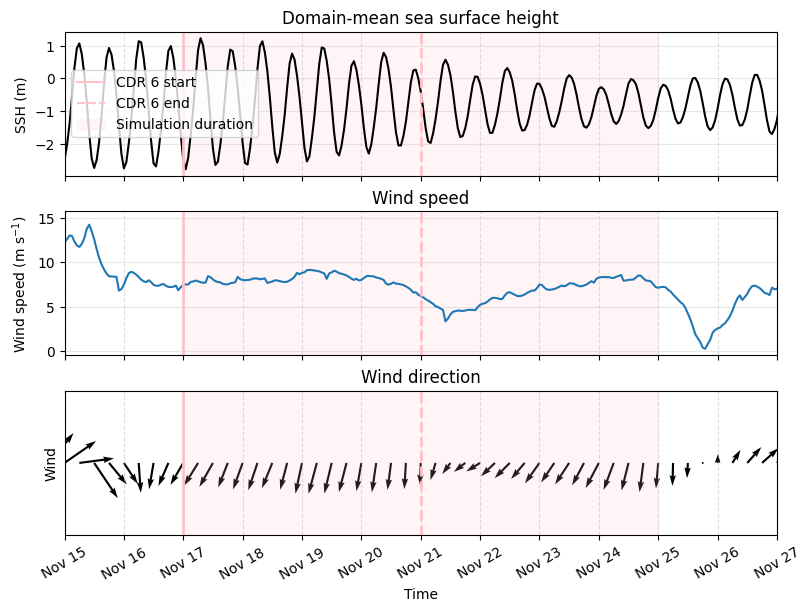

In [31]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-11-15")
x_end   = np.datetime64("2024-11-27")

for ax in axs:
    ax.set_xlim(x_start, x_end)


for ax in axs:
    ax.axvline(cdr_start, color="pink", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="pink", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="pink", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="pink", linestyle="-", label="CDR 6 start")
axs[0].plot([], [], color="pink", linestyle="--", label="CDR 6 end")
axs[0].fill_between([], [], [], color="pink", alpha=0.15, label="Simulation duration")

axs[0].legend()


This cell runs the next analysis step in the wind and tidal-conditions workflow.